# BrightSpot — Classical Segmentation Evaluation

Evaluates `classical_seg.nii` against ground truth `wmh.nii` for all training cases.

This gives us the **classical-only baseline** for our ablation study:
- Classical only (this notebook)
- U-Net baseline (to be added after training)
- Guided U-Net (to be added after training)

Metrics: DICE, Hausdorff95, Lesion-level F1

In [5]:
import sys
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Add repo root to path so we can import evaluation/metrics.py
REPO_ROOT = Path('/data/users/ssethi2/mmml_repos/guided-brightspot')
sys.path.insert(0, str(REPO_ROOT))

from evaluation.metrics import evaluate_case

PROCESSED_ROOT = REPO_ROOT / 'data' / 'processed' / 'training'
SITES = ['Utrecht', 'Singapore', 'Amsterdam/GE3T']
TARGET_SPACING = (1.0, 1.0, 3.0)  # x, y, z in mm

## 1. Run evaluation across all training cases

In [7]:
results = []

for site in SITES:
    site_dir = PROCESSED_ROOT / site
    if not site_dir.exists():
        print(f'WARNING: {site_dir} not found, skipping')
        continue

    for patient_dir in sorted(site_dir.iterdir(), key=lambda x: x.name):
        classical_path = patient_dir / 'classical_seg.nii'
        gt_path        = patient_dir / 'wmh.nii'

        if not classical_path.exists() or not gt_path.exists():
            print(f'WARNING: missing files for {site}/{patient_dir.name}, skipping')
            continue

        pred_arr = sitk.GetArrayFromImage(sitk.ReadImage(str(classical_path)))
        gt_arr   = sitk.GetArrayFromImage(sitk.ReadImage(str(gt_path)))

        metrics = evaluate_case(pred_arr, gt_arr, spacing=TARGET_SPACING)
        metrics['site']       = site
        metrics['patient_id'] = patient_dir.name
        results.append(metrics)

        print(f"{site:<20} {patient_dir.name:<6} "
              f"DICE={metrics['dice']:.3f}  "
              f"HD95={metrics['hausdorff95'] if metrics['hausdorff95'] != float('inf') else 'inf':<8}  "
              f"F1={metrics['f1']:.3f}  "
              f"GT lesions={metrics['n_gt_lesions']}  "
              f"Pred lesions={metrics['n_pred_lesions']}")

df = pd.DataFrame(results)
print(f'\nTotal cases evaluated: {len(df)}')

Utrecht              0      DICE=0.000  HD95=87.77     F1=0.000  GT lesions=118  Pred lesions=24
Utrecht              11     DICE=0.000  HD95=80.93     F1=0.000  GT lesions=69  Pred lesions=26
Utrecht              17     DICE=0.000  HD95=61.8      F1=0.000  GT lesions=49  Pred lesions=18
Utrecht              19     DICE=0.000  HD95=59.85     F1=0.000  GT lesions=109  Pred lesions=31
Utrecht              2      DICE=0.007  HD95=46.65     F1=0.000  GT lesions=178  Pred lesions=28
Utrecht              21     DICE=0.004  HD95=61.93     F1=0.000  GT lesions=150  Pred lesions=19
Utrecht              23     DICE=0.000  HD95=58.83     F1=0.000  GT lesions=27  Pred lesions=18
Utrecht              25     DICE=0.007  HD95=58.83     F1=0.000  GT lesions=53  Pred lesions=23
Utrecht              27     DICE=0.000  HD95=52.4      F1=0.000  GT lesions=22  Pred lesions=14
Utrecht              29     DICE=0.010  HD95=63.0      F1=0.000  GT lesions=110  Pred lesions=33
Utrecht              31     DICE=0.

## 2. Summary statistics — overall and per site

In [8]:
def summarize(df, label=''):
    # Exclude inf hausdorff from mean (keep count of inf cases)
    finite_hd = df[df['hausdorff95'] != np.inf]['hausdorff95']
    n_inf = (df['hausdorff95'] == np.inf).sum()

    print(f"\n{'='*55}")
    print(f" {label} (n={len(df)})")
    print(f"{'='*55}")
    print(f"  DICE        mean={df['dice'].mean():.3f}  std={df['dice'].std():.3f}  "
          f"min={df['dice'].min():.3f}  max={df['dice'].max():.3f}")
    print(f"  HD95 (mm)   mean={finite_hd.mean():.1f}  std={finite_hd.std():.1f}  "
          f"(inf cases: {n_inf})")
    print(f"  Precision   mean={df['precision'].mean():.3f}  std={df['precision'].std():.3f}")
    print(f"  Recall      mean={df['recall'].mean():.3f}  std={df['recall'].std():.3f}")
    print(f"  Lesion F1   mean={df['f1'].mean():.3f}  std={df['f1'].std():.3f}")

# Overall
summarize(df, label='ALL SITES — Classical Segmentation')

# Per site
for site in SITES:
    site_df = df[df['site'] == site]
    if len(site_df) > 0:
        summarize(site_df, label=f'{site}')


 ALL SITES — Classical Segmentation (n=60)
  DICE        mean=0.146  std=0.198  min=0.000  max=0.746
  HD95 (mm)   mean=60.1  std=15.0  (inf cases: 0)
  Precision   mean=0.043  std=0.069
  Recall      mean=0.019  std=0.025
  Lesion F1   mean=0.025  std=0.035

 Utrecht (n=20)
  DICE        mean=0.007  std=0.012  min=0.000  max=0.043
  HD95 (mm)   mean=61.6  std=11.9  (inf cases: 0)
  Precision   mean=0.000  std=0.000
  Recall      mean=0.000  std=0.000
  Lesion F1   mean=0.000  std=0.000

 Singapore (n=20)
  DICE        mean=0.228  std=0.191  min=0.000  max=0.615
  HD95 (mm)   mean=68.9  std=7.7  (inf cases: 0)
  Precision   mean=0.033  std=0.024
  Recall      mean=0.024  std=0.015
  Lesion F1   mean=0.027  std=0.016

 Amsterdam/GE3T (n=20)
  DICE        mean=0.202  std=0.234  min=0.000  max=0.746
  HD95 (mm)   mean=49.7  std=17.2  (inf cases: 0)
  Precision   mean=0.095  std=0.096
  Recall      mean=0.033  std=0.032
  Lesion F1   mean=0.048  std=0.047


## 3. Visualise metric distributions

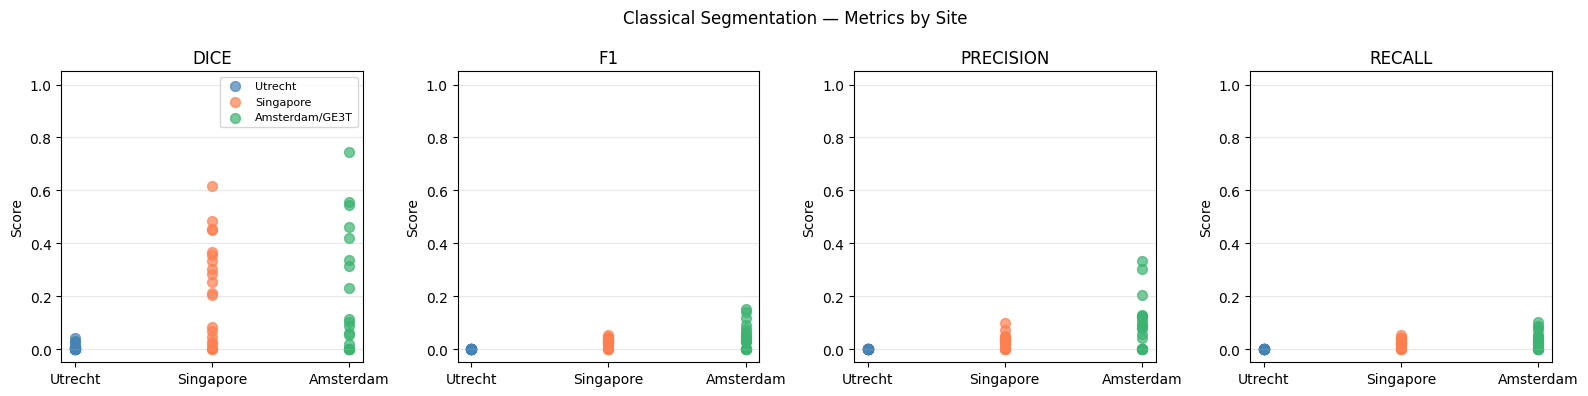

Saved to classical_metrics_by_site.png


In [9]:
metrics_to_plot = ['dice', 'f1', 'precision', 'recall']
site_colors = {'Utrecht': 'steelblue', 'Singapore': 'coral', 'Amsterdam/GE3T': 'mediumseagreen'}

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 4))

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    for site, color in site_colors.items():
        site_vals = df[df['site'] == site][metric]
        ax.scatter([site.split('/')[0]] * len(site_vals), site_vals,
                   color=color, alpha=0.7, s=50, label=site)
        ax.plot([site.split('/')[0]] * 2,
                [site_vals.mean(), site_vals.mean()],
                color=color, linewidth=3)
    ax.set_title(metric.upper())
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)

axes[0].legend(fontsize=8)
plt.suptitle('Classical Segmentation — Metrics by Site', fontsize=12)
plt.tight_layout()
plt.savefig('classical_metrics_by_site.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to classical_metrics_by_site.png')

## 4. Flag outlier cases
Cases with very low DICE — worth inspecting visually

In [10]:
LOW_DICE_THRESHOLD = 0.2
low_dice = df[df['dice'] < LOW_DICE_THRESHOLD].sort_values('dice')

if len(low_dice) == 0:
    print(f'No cases with DICE < {LOW_DICE_THRESHOLD}')
else:
    print(f'{len(low_dice)} cases with DICE < {LOW_DICE_THRESHOLD}:')
    print(low_dice[['site', 'patient_id', 'dice', 'hausdorff95',
                     'n_gt_lesions', 'n_pred_lesions']].to_string(index=False))

40 cases with DICE < 0.2:
          site patient_id   dice  hausdorff95  n_gt_lesions  n_pred_lesions
       Utrecht          0 0.0000        87.77           118              24
       Utrecht         11 0.0000        80.93            69              26
       Utrecht         17 0.0000        61.80            49              18
       Utrecht         19 0.0000        59.85           109              31
       Utrecht         23 0.0000        58.83            27              18
       Utrecht          4 0.0000        51.72            92              38
       Utrecht         33 0.0000        63.41            80              26
       Utrecht         27 0.0000        52.40            22              14
       Utrecht         35 0.0000        69.49            53              27
Amsterdam/GE3T        106 0.0000        64.58            26              21
Amsterdam/GE3T        102 0.0000        57.59           137              22
     Singapore         54 0.0000        82.06            19   

## 5. Visual inspection — best, median, and worst DICE cases

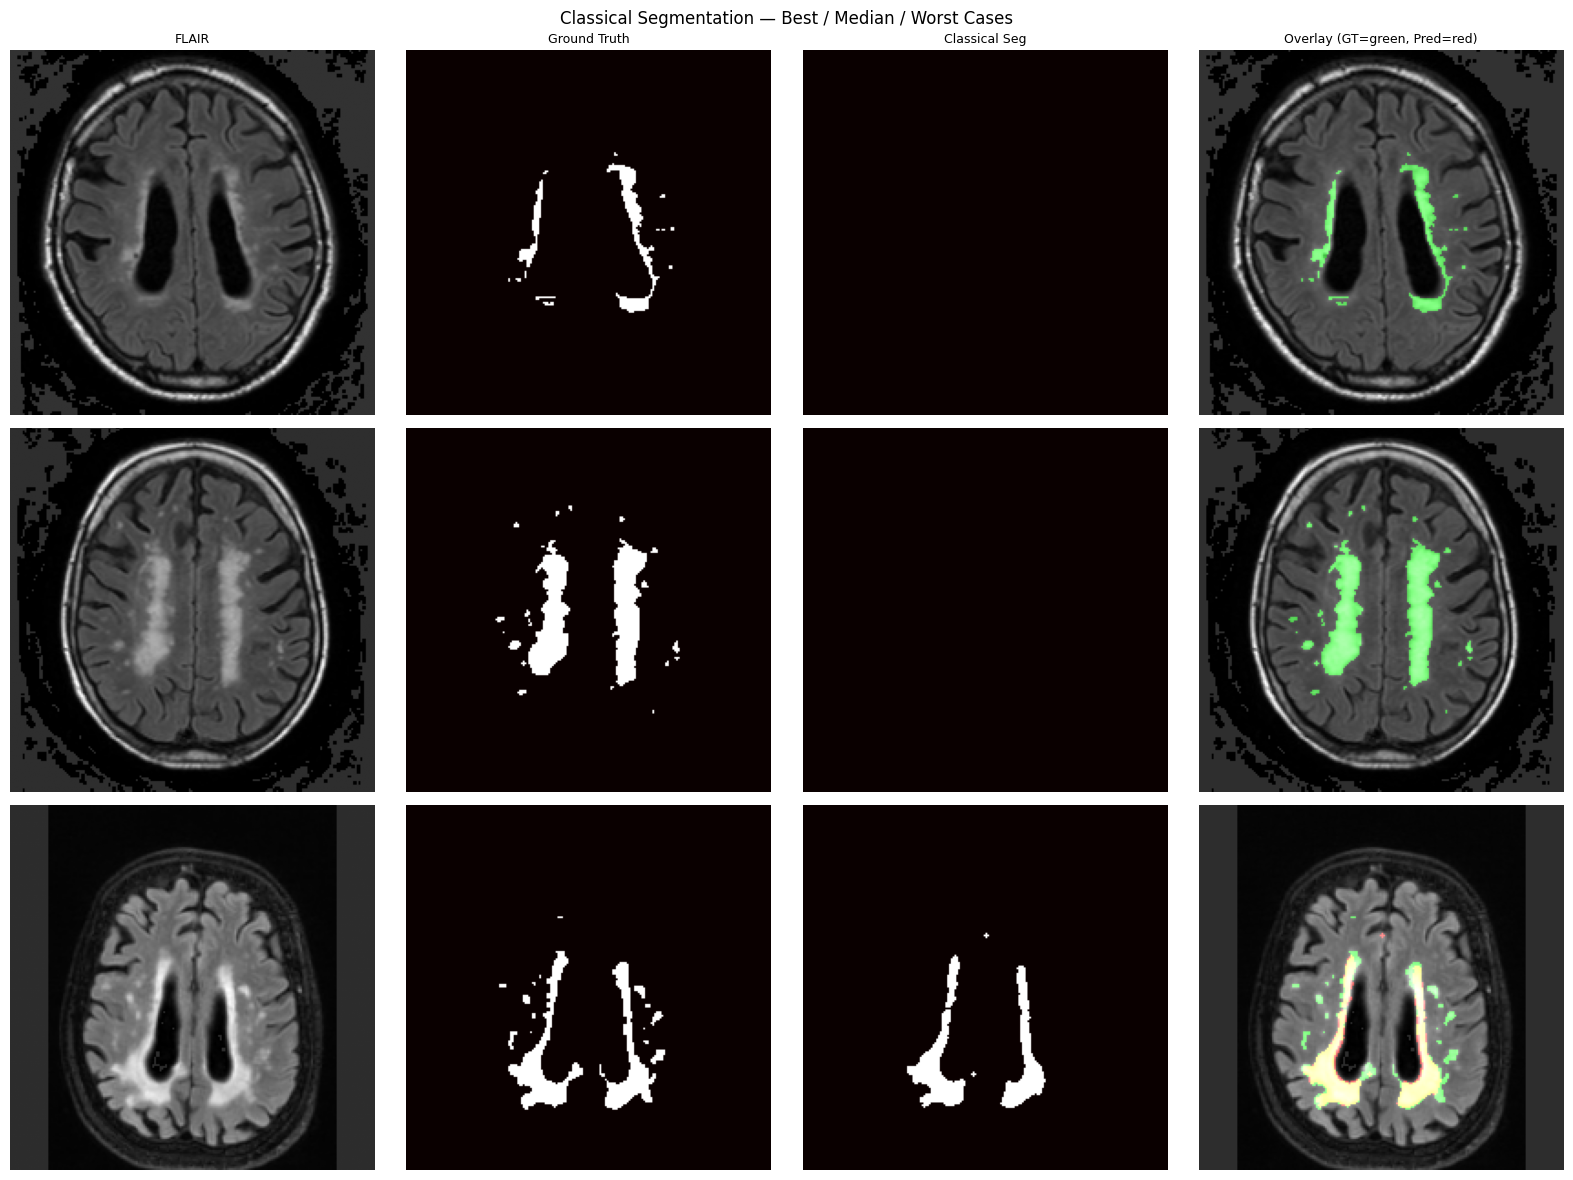

Saved to classical_qualitative.png


In [12]:
def normalize_display(arr):
    mn, mx = arr.min(), arr.max()
    return (arr.astype(float) - mn) / (mx - mn) if mx > mn else arr.astype(float)

def best_slice(wmh_arr):
    counts = wmh_arr.sum(axis=(1, 2))
    best = int(counts.argmax())
    return best if counts[best] > 0 else wmh_arr.shape[0] // 2

# Pick best, median, worst DICE cases
df_sorted = df.sort_values('dice')
cases_to_show = {
    f"Worst  (DICE={df_sorted.iloc[0]['dice']:.3f})": df_sorted.iloc[0],
    f"Median (DICE={df_sorted.iloc[len(df_sorted)//2]['dice']:.3f})": df_sorted.iloc[len(df_sorted)//2],
    f"Best   (DICE={df_sorted.iloc[-1]['dice']:.3f})": df_sorted.iloc[-1],
}

fig, axes = plt.subplots(len(cases_to_show), 4, figsize=(16, 4 * len(cases_to_show)))
col_labels = ['FLAIR', 'Ground Truth', 'Classical Seg', 'Overlay (GT=green, Pred=red)']

for row, (label, case_row) in enumerate(cases_to_show.items()):
    site = case_row['site']
    pid  = case_row['patient_id']
    pdir = PROCESSED_ROOT / site / pid

    flair_arr = sitk.GetArrayFromImage(sitk.ReadImage(str(pdir / 'FLAIR.nii')))
    gt_arr    = sitk.GetArrayFromImage(sitk.ReadImage(str(pdir / 'wmh.nii')))
    pred_arr  = sitk.GetArrayFromImage(sitk.ReadImage(str(pdir / 'classical_seg.nii')))

    sl = best_slice(gt_arr)
    f_sl = flair_arr[sl]
    g_sl = gt_arr[sl]
    p_sl = pred_arr[sl]

    ax = axes[row]
    ax[0].imshow(normalize_display(f_sl), cmap='gray')
    ax[0].set_ylabel(f'{label}\n{site}/{pid}', fontsize=8)
    ax[1].imshow(g_sl, cmap='hot', vmin=0, vmax=1)
    ax[2].imshow(p_sl, cmap='hot', vmin=0, vmax=1)

    # Overlay: GT in green, Pred in red, overlap in yellow
    overlay = np.zeros((*f_sl.shape, 3))
    flair_norm = normalize_display(f_sl)
    overlay[:,:,0] = flair_norm
    overlay[:,:,1] = flair_norm
    overlay[:,:,2] = flair_norm
    # GT = green channel boost
    overlay[:,:,1] = np.clip(overlay[:,:,1] + 0.5 * g_sl, 0, 1)
    # Pred = red channel boost
    overlay[:,:,0] = np.clip(overlay[:,:,0] + 0.5 * p_sl, 0, 1)
    ax[3].imshow(overlay)

    for i, a in enumerate(ax):
        if row == 0:
            a.set_title(col_labels[i], fontsize=9)
        a.axis('off')

plt.suptitle('Classical Segmentation — Best / Median / Worst Cases', fontsize=12)
plt.tight_layout()
plt.savefig('classical_qualitative.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to classical_qualitative.png')

## 6. Save results to CSV for later comparison

In [13]:
out_csv = REPO_ROOT / 'outputs' / 'classical_results.csv'
out_csv.parent.mkdir(parents=True, exist_ok=True)
df['method'] = 'classical'
df.to_csv(out_csv, index=False)
print(f'Results saved to {out_csv}')
print('\nThis CSV will be loaded later alongside U-Net and guided U-Net results for final comparison.')

Results saved to /data/users/ssethi2/mmml_repos/guided-brightspot/outputs/classical_results.csv

This CSV will be loaded later alongside U-Net and guided U-Net results for final comparison.
